<a href="https://colab.research.google.com/github/RajManish8340/micro-gradient-descent/blob/main/gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [168]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [169]:
def f(x):
  return x**2 + 7


In [170]:
f(3)

16

(200,)


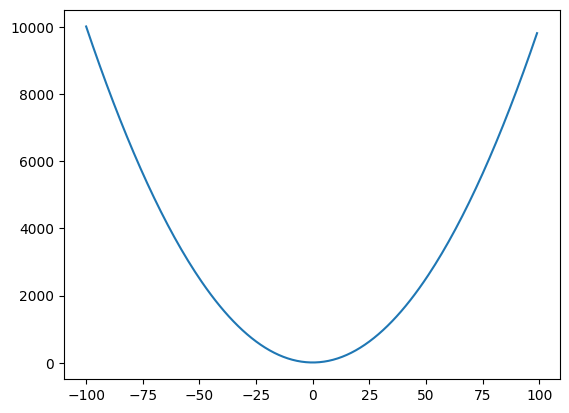

In [171]:
xs = np.arange(-100, 100, 1)
ys = f(xs)
print(ys.shape)

plt.plot(xs, ys)
plt.show()

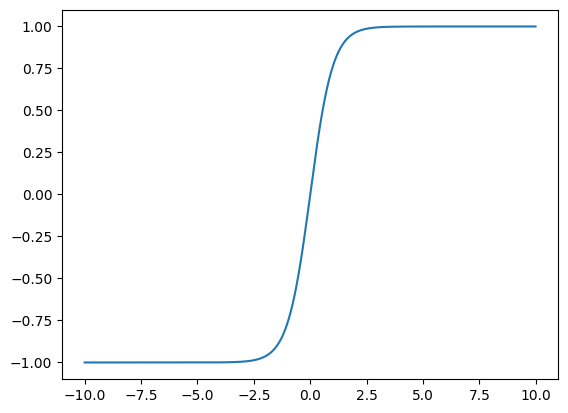

In [172]:
xs = np.arange(-10,10,0.01, dtype=np.float128)
def t(x):
  return (np.exp(2*x) - 1)/(np.exp(2*x) + 1)
tan = t(xs)

plt.plot(xs,tan)
plt.show()
# tanh is an activations function which makes the outpt zero centered and if the values are greated it makes them values to 1 and -1

In [173]:
h = 0.000001
x = 3

(f(x + h) - f(x))/h  # this is the differentiating the function wrt x i.e 2x


6.000001000927568

In [174]:
h = 0.0001

a = 3
b = -5
c = 8

d1 = b*c + a
a += h
d2 = b*c + a

print("d1", d1)
print("d2", d2)
print("derivative wrt a", (d2 - d1)/h) # derivate of the function wrt a is 1

d1 -37
d2 -36.9999
derivative wrt a 1.0000000000331966


In [175]:
class Value:

   # chldren is a tuple not a set as it could cause bugs if the both self and other are same
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    # because _prev represents unique nodes in the graph,
    # while _backward() still has access to both self and other and therefore knows that a was used twice.
    self._prev = set(_children) # converts tuple into a set (just the prev operands of current)
    self.label = label
    self.grad = 0
    self._backward = lambda: None
    self._op = _op

  def __repr__(self):
    return (f"Value(data={self.data})")

  def __add__(self, other):
    # this is for if there is something like other.__init__(self),
    # so the functions are also valid for the other if it is not a Value
    # we are making it one Value(other)
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1*out.grad
      other.grad += 1*out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __pow__(self, other):
    # only support for int and float powers
    # stop the program and give error if not so
    assert isinstance(other, (int, float))
    # here other is not a Value object so we do not need other.data
    # its stricly int or float
    out = Value(self.data ** other, (self, ), f'**{other}')

    # other is a a number not object so not other.data
    def _backward():
      self.grad += other * (self.data**(other-1)) * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other):
    return self * other

  def __truediv__(self, other):
    return self * other**-1

  def __neg__(self):
    return self * -1

  def __radd__(self, other):
    return self + other

  def __sub__(self, other):
    return self + (-other)

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self,), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward

    return out

  def backward(self):

    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited :
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()



In [176]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [177]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weigths w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')

# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label='x1w1'
x2w2 = x2*w2; x2w2.label='x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1 + x2w2'
n = x1w1x2w2 + b; n.label='n'
o = n.tanh(); o.label='o'
o.backward()

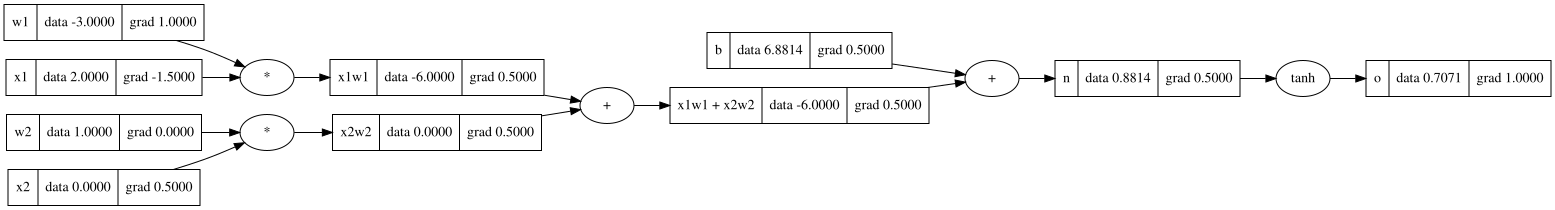

In [178]:
draw_dot(o)

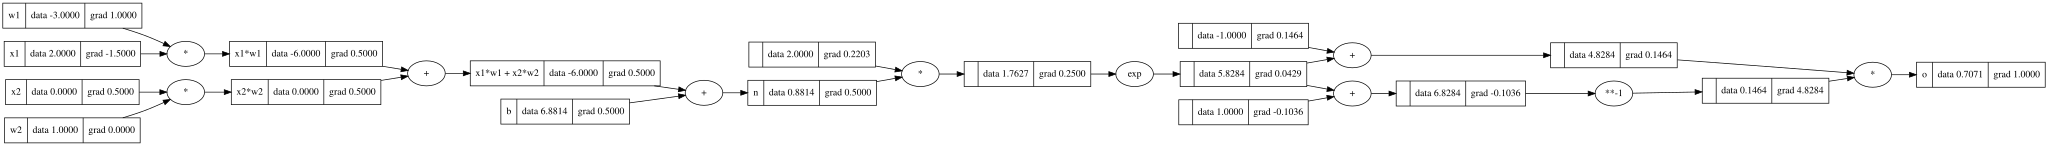

In [179]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp()
o = (e - 1) / (e + 1); o.label = 'o'

o.backward()
draw_dot(o)

In [180]:
class Neuron:
  def __init__(self, nin):
    # draws random values from uniform(not normal dist) distribution between -1,1
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    # tanh is a nonlinear activation function that squashes values between -1 and 1
    # and is zero-centered: tanh(0) = 0
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b] # because self.w is list so we make self.b also a list

class Layer:
   # nin = number of inputs each neuron receives
   # nout = number of neurons in this layer
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs # return Value if layer has only 1 neuron

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

  def __init__(self, nin, nouts): # nouts is the list of neurons per layer
    sz = [nin] + nouts
    # sz[i] = number of inputs to the current layer
    # sz[i+1] = number of neurons in the current layer
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [181]:
#MLP
# │
# ├── Layer
# │    ├── Neuron
# │    │    ├── weights
# │    │    └── bias
# │    └── Neuron
# │
# └── Layer
#      └── ...

In [182]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1]) # 3 inputs and layers with 4 , 4 , 1 neurons
n(x) # calls MLP.__call__(), passing x through each layer and returning the final output

Value(data=0.609906531610404)

In [183]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
] # given inputs
# each neuron has randomly initialized weights and bias

# for given xs as inputs desired outputs ys
ys = [1.0, -1.0, -1.0, 1.0] # for givene x[0] as input expected output is y[0]

In [184]:
#n.parameters()
#       ↓
#all layers
#       ↓
#all neurons
#       ↓
#all weights + biases

In [185]:
#                 FORWARD
#                    ↓
#             make predictions
#                    ↓
#              calculate loss
#                    ↓
#                 BACKWARD
#                    ↓
#             calculate gradients
#                    ↓
#           update weights/biases
#                    ↓
#                 repeat

In [186]:
for k in range(30):

  # forward pass
  ypred = [n(x) for x in xs] # generate predictions using the current weights and biases
  loss  = sum((yout - ygt)**2 for yout, ygt in zip(ypred, ys)) # sum of sqare of diffrence loss

  # backward pass
  for p in n.parameters():
    p.grad = 0.0 # reset gradients of all weights and biases
  # because loss is the final equation we are genrating and we can go backward from
  # here and calculate how much which weight contributed to give this much loss and late
  # update thsese
  # Starting from this final loss, work backward through the entire computation graph
  # and determine how much each weight and bias contributed to the loss.
  loss.backward() # bakcward function on loss

  # update
  for p in n.parameters():

    # move parameters in the opposite direction of the gradient to reduce the loss
    # 0.1 is the learning rate, which controls the step size
    p.data += -0.1*p.grad

  print(k, loss)


0 Value(data=1.8755432961888188)
1 Value(data=0.4465963784236311)
2 Value(data=0.13096950440723437)
3 Value(data=0.07434208111285825)
4 Value(data=0.0573764792138555)
5 Value(data=0.04763478514829378)
6 Value(data=0.040996735032107684)
7 Value(data=0.036077722338603145)
8 Value(data=0.03224594636673504)
9 Value(data=0.02915967648714588)
10 Value(data=0.02661294399789444)
11 Value(data=0.02447205627026578)
12 Value(data=0.022645465487442822)
13 Value(data=0.021067904344549023)
14 Value(data=0.019691353346789706)
15 Value(data=0.01847957607813457)
16 Value(data=0.017404650034761122)
17 Value(data=0.01644467677503696)
18 Value(data=0.015582221110576885)
19 Value(data=0.014803218148357557)
20 Value(data=0.014096190167368565)
21 Value(data=0.01345167426496488)
22 Value(data=0.0128617967429191)
23 Value(data=0.012319951741121743)
24 Value(data=0.011820555262530267)
25 Value(data=0.011358854590809484)
26 Value(data=0.010930778988492113)
27 Value(data=0.010532821555063394)
28 Value(data=0.0101

In [187]:
ypred

[Value(data=0.958980425251433),
 Value(data=-0.9650867276469413),
 Value(data=-0.9339047539191736),
 Value(data=0.9495482268839023)]